In [1]:
import sys
sys.path.append("..")

In [2]:
import json
import os
from src.utils import read_index, get_device
from src.evaluate import _MODEL_REGISTRY, _retrieve
import polars as pl
import numpy as np
from argparse import Namespace

In [3]:
test_df = pl.read_csv("/mnt/yokoyamalab-nas/gldv2-full/csv/v2/test.csv").with_row_index("row_idx")
test_df.head()

row_idx,id,landmark_id,latitude,longitude,wikimedia_url,geohack_url,country_code,country,region,subregion,src,pred_label,pred_score,caption,stratify_key
u32,str,i64,f64,f64,str,str,str,str,str,str,str,str,f64,str,str
0,"""cfa552a8ad62142a""",158118,55.249983,-4.366351,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""GB""","""United Kingdom""","""Europe""","""Northern Europe""","""train""","""arch_gate""",0.9,"""Ancient stone ruins with a cen…","""United Kingdom|arch_gate"""
1,"""b76fefa8adbdd62e""",63887,33.36425,132.513611,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""JP""","""Japan""","""Asia""","""Eastern Asia""","""train""","""palace_castle""",0.9,"""Traditional Japanese building …","""Japan|palace_castle"""
2,"""3142152099d53719""",156682,8.077778,77.553889,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""IN""","""India""","""Asia""","""Southern Asia""","""train""","""monument_statue""",0.9,"""A large statue of a figure hol…","""India|monument_statue"""
3,"""93594417929f7cd7""",21401,8.508611,76.955,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""IN""","""India""","""Asia""","""Southern Asia""","""index""","""monument_statue""",0.9,"""Two stone pillars with bullet …","""India|monument_statue"""
4,"""f2dd46ae304a7f03""",140564,54.121389,-0.905833,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""GB""","""United Kingdom""","""Europe""","""Northern Europe""","""train""","""palace_castle""",0.9,"""Palace with classical architec…","""United Kingdom|palace_castle"""


In [4]:
test_queries = json.loads(open("/mnt/yokoyamalab-nas/gldv2-full/csv/v2/test_augmented_queries.json", "r").read())
test_queries = test_queries["data"]

In [5]:
BASE_INDEX_PATH = "../index/gld-v2/"
clip_index, _ = read_index(os.path.join(BASE_INDEX_PATH, "baseline-clip-gldv-merged-v2"))
g3_index, _ = read_index(os.path.join(BASE_INDEX_PATH, "baseline-g3-gldv-merged-v2"))
geoclip_index, _ = read_index(os.path.join(BASE_INDEX_PATH, "baseline-geoclip-gldv-merged-v2"))
geotir_vlm_index, _ = read_index(os.path.join(BASE_INDEX_PATH, "geotir-vlm-caption-gldv-merged-v2"))
geotir_template_index, _ = read_index(os.path.join(BASE_INDEX_PATH, "geotir-template-caption-gldv-merged-v2"))

In [6]:
all_top5_results = {}
query = [test_queries[100]]
topk = 5
bs = 1
print(query[0]["text"])

Medieval brick tower or fortification in the Netherlands


In [7]:
# clip
clip_encode_fn = _MODEL_REGISTRY["clip"](None, get_device())
clip_query_embeds = clip_encode_fn(query, bs).numpy()
clip_indices = _retrieve(clip_index, clip_query_embeds, topk).squeeze().tolist()
clip_indices_meta = test_df.filter(pl.col("row_idx").is_in(clip_indices)).to_dicts()
all_top5_results["CLIP-ZS"] = clip_indices_meta
clip_summary = np.isin(np.array(clip_indices), np.array(query[0]["relevant_indices"]))
print(f"{clip_summary.sum().item()}/{len(clip_summary)}")

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


3/5


In [8]:
# geoclip
geoclip_encode_fn = _MODEL_REGISTRY["geoclip"](None, get_device())
geoclip_query_embeds = geoclip_encode_fn(query, bs).numpy()
geoclip_indices = _retrieve(geoclip_index, geoclip_query_embeds, topk).squeeze().tolist()
geoclip_indices_meta = test_df.filter(pl.col("row_idx").is_in(geoclip_indices)).to_dicts()
all_top5_results["GeoCLIP"] = geoclip_indices_meta
geoclip_summary = np.isin(np.array(geoclip_indices), np.array(query[0]["relevant_indices"]))
print(f"{geoclip_summary.sum().item()}/{len(geoclip_summary)}")

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


1/5


In [9]:
# g3
g3_encode_fn = _MODEL_REGISTRY["g3"](None, get_device())
g3_query_embeds = g3_encode_fn(query, bs).numpy()
g3_indices = _retrieve(g3_index, g3_query_embeds, topk).squeeze().tolist()
g3_indices_meta = test_df.filter(pl.col("row_idx").is_in(g3_indices)).to_dicts()
all_top5_results["G3"] = g3_indices_meta
g3_summary = np.isin(np.array(g3_indices), np.array(query[0]["relevant_indices"]))
print(f"{g3_summary.sum().item()}/{len(g3_summary)}")

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


0/5


In [10]:
# geotir_vlm
args = Namespace(ckpt_path="../checkpoints/gld-v2/gldv-merged-v2-vlm-caption-no-sampler/best.pt")
geotir_vlm_encode_fn = _MODEL_REGISTRY["geotir"](args, get_device())
geotir_vlm_query_embeds = geotir_vlm_encode_fn(query, bs).numpy()
geotir_vlm_indices = _retrieve(geotir_vlm_index, geotir_vlm_query_embeds, topk).squeeze().tolist()
geotir_vlm_indices_meta = test_df.filter(pl.col("row_idx").is_in(geotir_vlm_indices)).to_dicts()
all_top5_results["CLIP-FT\n(VLM Caption)"] = geotir_vlm_indices_meta
geotir_vlm_summary = np.isin(np.array(geotir_vlm_indices), np.array(query[0]["relevant_indices"]))
print(f"{geotir_vlm_summary.sum().item()}/{len(geotir_vlm_summary)}")


Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


trainable params: 2,162,688 || all params: 429,779,201 || trainable%: 0.5032
5/5


In [11]:
# geotir_template
args = Namespace(ckpt_path="../checkpoints/gld-v2/gldv-merged-v2-template-caption-no-sampler/best.pt")
geotir_template_encode_fn = _MODEL_REGISTRY["geotir"](args, get_device())
geotir_template_query_embeds = geotir_template_encode_fn(query, bs).numpy()
geotir_template_indices = _retrieve(geotir_template_index, geotir_template_query_embeds, topk).squeeze().tolist()
geotir_template_indices_meta = test_df.filter(pl.col("row_idx").is_in(geotir_template_indices)).to_dicts()
all_top5_results["CLIP-FT\n(Template)"] = geotir_template_indices_meta
geotir_template_summary = np.isin(np.array(geotir_template_indices), np.array(query[0]["relevant_indices"]))
print(f"{geotir_template_summary.sum().item()}/{len(geotir_template_summary)}")

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


trainable params: 2,162,688 || all params: 429,779,201 || trainable%: 0.5032
1/5


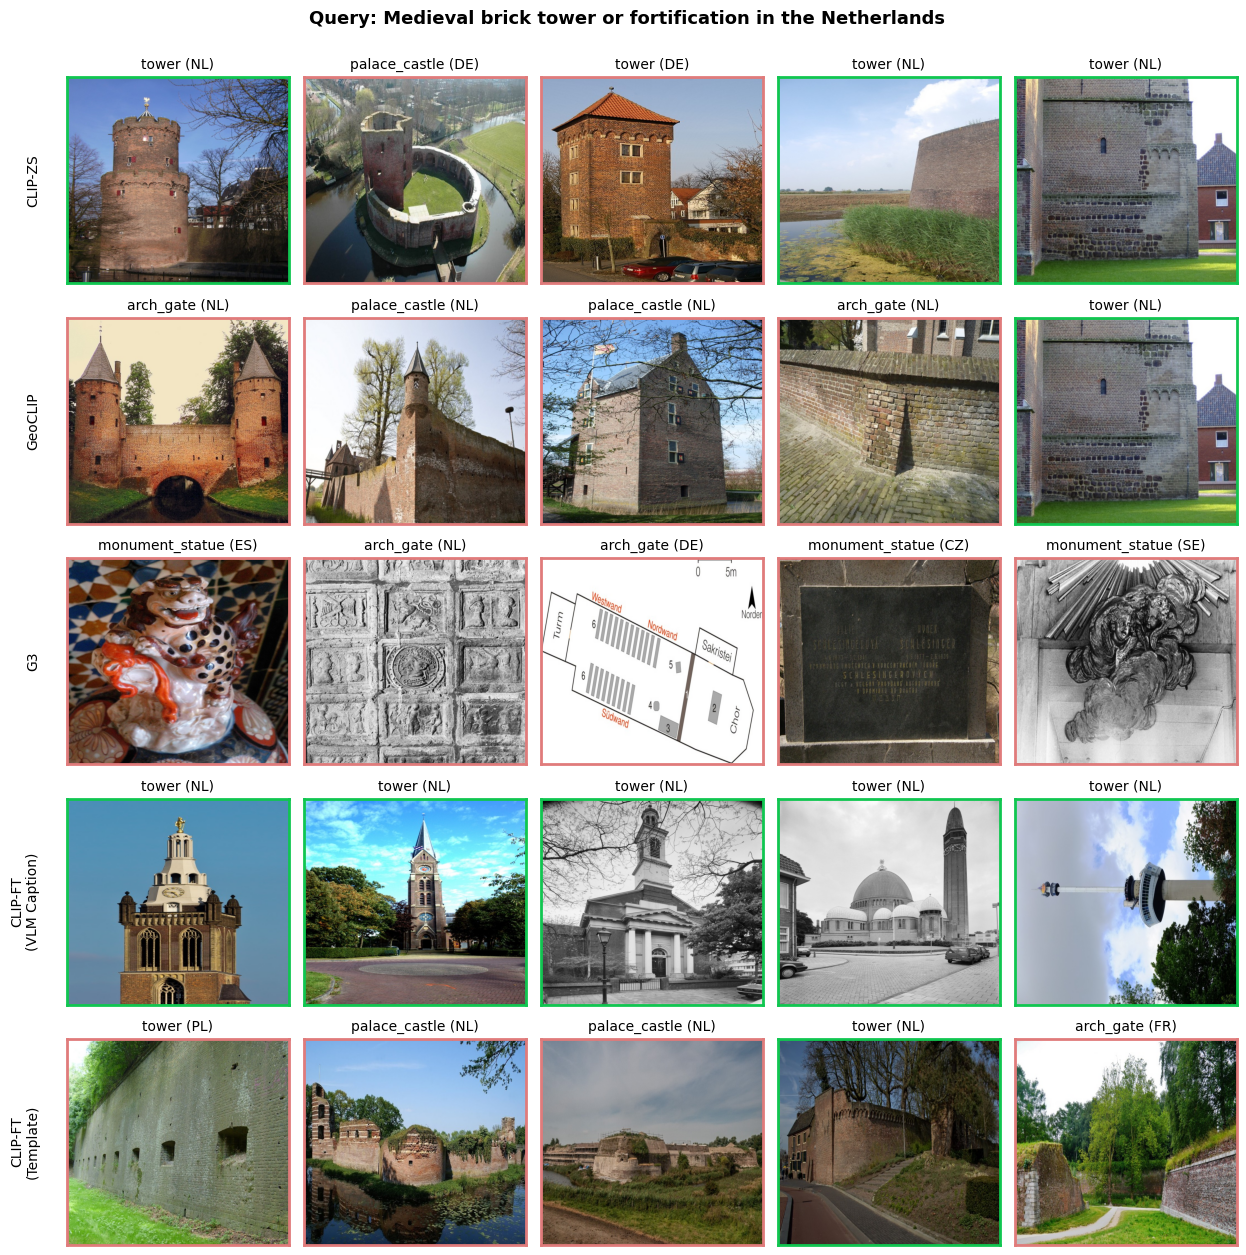

In [12]:
import matplotlib.pyplot as plt
from PIL import Image

BASE_IMAGE_PATH = "/mnt/yokoyamalab-nas/gldv2-full/"

def load_image(meta):
    path = os.path.join(BASE_IMAGE_PATH, meta["src"], f"{meta['id']}.jpg")
    return Image.open(path).convert("RGB")

nrows = len(all_top5_results)
ncols = topk

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.5, nrows * 2.5))
fig.suptitle(f'Query: {query[0]["text"]}', y=1, fontsize=13, fontweight="bold")

LABEL_X = -0.12
relevant = set(query[0]["relevant_indices"])

for row, model_name in enumerate(all_top5_results):
    for col, meta in enumerate(all_top5_results[model_name]):
        ax = axes[row][col]
        ax.imshow(load_image(meta), aspect='auto')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f"{meta['pred_label']} ({meta['country_code']})", fontsize=10)
        border_color = "#10C650" if meta['row_idx'] in relevant else '#E07B7B'
        for spine in ax.spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(2)
    axes[row][0].set_ylabel(model_name, rotation=90)
    axes[row][0].yaxis.set_label_coords(LABEL_X, 0.5)

plt.tight_layout()
fig.savefig("../outputs/query_result.png")
plt.show()

### Inference on OOD Asean dataset

In [22]:
import sys
sys.path.append("..")
import json
import os
from src.utils import read_index, get_device
from src.data.query_builder import build_queries, augment_queries
from src.evaluate import _load_index_and_queries, read_index
from src.evaluate import _MODEL_REGISTRY, _retrieve
import polars as pl
import numpy as np
from argparse import Namespace

In [24]:
ood_df = pl.read_csv("/mnt/yokoyamalab-nas/gldv2-full/csv/v2-ext/test_w_ood.csv").with_row_index("row_idx")
ood_df.head()

row_idx,id,landmark_id,latitude,longitude,wikimedia_url,geohack_url,country_code,country,region,subregion,src,category,pred_score,caption,stratify_key
u32,str,i64,f64,f64,str,str,str,str,str,str,str,str,f64,str,str
0,"""cfa552a8ad62142a""",158118,55.249983,-4.366351,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""GB""","""United Kingdom""","""Europe""","""Northern Europe""","""train""","""arch_gate""",0.9,"""Ancient stone ruins with a cen…","""United Kingdom|arch_gate"""
1,"""b76fefa8adbdd62e""",63887,33.36425,132.513611,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""JP""","""Japan""","""Asia""","""Eastern Asia""","""train""","""palace_castle""",0.9,"""Traditional Japanese building …","""Japan|palace_castle"""
2,"""3142152099d53719""",156682,8.077778,77.553889,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""IN""","""India""","""Asia""","""Southern Asia""","""train""","""monument_statue""",0.9,"""A large statue of a figure hol…","""India|monument_statue"""
3,"""93594417929f7cd7""",21401,8.508611,76.955,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""IN""","""India""","""Asia""","""Southern Asia""","""index""","""monument_statue""",0.9,"""Two stone pillars with bullet …","""India|monument_statue"""
4,"""f2dd46ae304a7f03""",140564,54.121389,-0.905833,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""GB""","""United Kingdom""","""Europe""","""Northern Europe""","""train""","""palace_castle""",0.9,"""Palace with classical architec…","""United Kingdom|palace_castle"""


In [28]:
ood_df["subregion"].unique().to_numpy().squeeze()

array(['South-eastern Asia', 'Eastern Asia', 'Northern America',
       'Northern Europe', 'Western Europe', 'Southern Europe',
       'Southern Asia', 'Eastern Europe'], dtype=object)

In [32]:
asean_df = ood_df.filter(pl.col("subregion") == "South-eastern Asia")
template_queries = build_queries(asean_df)
augment = await augment_queries(asean_df)

[WARN] (palace_castle, Timor Leste) key has less than 5 relevant indices
[WARN] (tower, Timor Leste) key has less than 5 relevant indices
[WARN] (bridge, Timor Leste) key has less than 5 relevant indices


augmenting captions: 100%|██████████| 52/52 [00:21<00:00,  2.45it/s]


In [35]:
with open("/mnt/yokoyamalab-nas/gldv2-full/csv/v2-ext/ood_templated_queries.json", "w") as f:
    f.write(json.dumps({"data": template_queries}))

In [40]:
new_queries = []
for res in augment:
    country, category = res["stratify_key"].split("|")
    try:
        sample = list(filter(lambda x: (x["category"] == category) and (x["country"] == country), template_queries))[0]

        new_queries.append(sample)
        for r in res["augmented_captions"]:
            item = sample.copy()
            item["text"] = r
            new_queries.append(item)
    except Exception as e:
        print(country, category)
        print(e)

# print(len(uk_queries))
len(new_queries)

Timor Leste bridge
list index out of range
Timor Leste tower
list index out of range
Timor Leste palace_castle
list index out of range


294

In [44]:
with open("/mnt/yokoyamalab-nas/gldv2-full/csv/v2-ext/ood_augmented_queries.json", "w") as f:
    f.write(json.dumps({"data": new_queries}))